# Stratospheric wind: exploratory analysis

What this notebook is for: understanding the 50 hPa wind field over South Asia
well enough to justify the forecasting setup that follows. Specifically, whether
the series is predictable at all at 6-24 h, what the seasonal structure is, and
whether altitude gives an airship a second control lever.

Everything heavy lives in `src/`. This notebook is the narrative; run
`python src/eda.py` to regenerate every figure as a file.


In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import config as C
import data as D
import eda
import viz

viz.apply_style()
print("levels (hPa):", C.LEVELS_HPA)
print("station:", C.TARGET_LAT, "N", C.TARGET_LON, "E")
print("sampling:", C.STEP_HOURS, "h -> input window", C.INPUT_STEPS,
      "steps, horizons", C.HORIZON_STEPS, "steps")

levels (hPa): [50, 30, 10]
station: 20.0 N 80.0 E
sampling: 3 h -> input window 8 steps, horizons [2, 4, 8] steps


## 1. Load the record

`open_raw` stitches the monthly ERA5 files into one time-sorted dataset and drops
any duplicate timestamps left behind by a retried download. `station_frame` pulls
the vertical column above the station, `add_derived` adds speed, direction and
shear, and `clean` puts the series on a gapless axis so that a missing timestamp
becomes a visible NaN rather than silently vanishing.

In [2]:
ds = D.open_raw()
print("grid:", dict(ds.sizes))
print("period:", str(ds.valid_time.values[0])[:16], "->", str(ds.valid_time.values[-1])[:16])

raw = D.add_derived(D.station_frame(ds))
df, missing = D.clean(raw)
print("steps:", len(df), "| imputed cells:", int(missing.to_numpy().sum()))
df.head()

grid: {'valid_time': 8768, 'pressure_level': 3, 'latitude': 31, 'longitude': 41}
period: 2022-01-01T00:00 -> 2024-12-31T21:00


steps: 8768 | imputed cells: 0


,u50,v50,t50,u30,v30,t30,u10,v10,t10,speed50,dir50,speed30,dir30,speed10,dir10,shear_10_50,hour_sin,hour_cos
time,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,3.384109,0.663940,209.002838,1.662537,-1.034119,215.397736,13.639175,8.618652,223.156235,3.448625,258.899933,1.957915,301.882141,16.134071,237.711044,12.685447,0.000000e+00,1.000000e+00
2022-01-01 03:00:00,3.305496,-2.636322,209.653122,1.034409,0.561951,215.404205,16.207062,5.480438,222.002914,4.228061,308.574371,1.177196,241.486633,17.108597,251.316986,12.880536,7.071068e-01,7.071068e-01
2022-01-01 06:00:00,2.599274,-1.703033,207.814911,2.201675,0.794312,216.507568,17.182037,2.255524,219.457520,3.107498,303.232666,2.340578,250.161774,17.329449,262.521423,14.221951,1.000000e+00,6.123234e-17
2022-01-01 09:00:00,3.634140,-0.794724,206.366058,3.489212,2.554077,215.134552,15.174469,0.645737,218.672638,3.720021,282.335419,4.324108,233.796158,15.188202,267.563293,11.468181,7.071068e-01,-7.071068e-01
2022-01-01 12:00:00,3.318832,0.502090,207.798325,2.985245,1.725937,214.517807,10.186707,-3.134613,219.788177,3.356597,261.397247,3.448267,239.965393,10.658086,287.103973,7.301489,1.224647e-16,-1.000000e+00


## 2. Statistics

The temperature column is the first sanity check: around 209 K at 50 hPa is right
for the tropical lower stratosphere, so the levels are what we asked for.

In [3]:
stats = eda.stats_table(df)
stats

,n,mean,std,min,25%,50%,75%,max,units
speed50,8768,10.534,7.168,0.082,4.699,8.404,15.997,35.479,m/s
speed30,8768,11.848,7.419,0.018,5.506,10.525,17.554,39.260,m/s
speed10,8768,14.111,9.186,0.151,6.559,11.943,20.633,47.577,m/s
u50,8768,-5.721,10.999,-34.630,-15.346,-4.072,3.594,22.225,m/s
u30,8768,-8.506,10.679,-38.841,-17.216,-8.686,-0.474,22.935,m/s
u10,8768,-11.093,12.092,-44.642,-20.394,-10.617,-1.748,18.373,m/s
v50,8768,-0.163,2.936,-13.275,-2.064,-0.176,1.739,10.247,m/s
v30,8768,0.040,3.005,-10.946,-1.919,0.046,2.039,11.030,m/s
v10,8768,-0.173,3.771,-20.350,-2.605,-0.167,2.283,16.955,m/s
t50,8768,206.887,2.621,196.540,205.307,207.192,208.688,215.055,K


## 3. The series itself

Three things to look for: the wind is smooth rather than noisy, the zonal
component changes sign between seasons, and 10 hPa is consistently windier than
50 hPa.

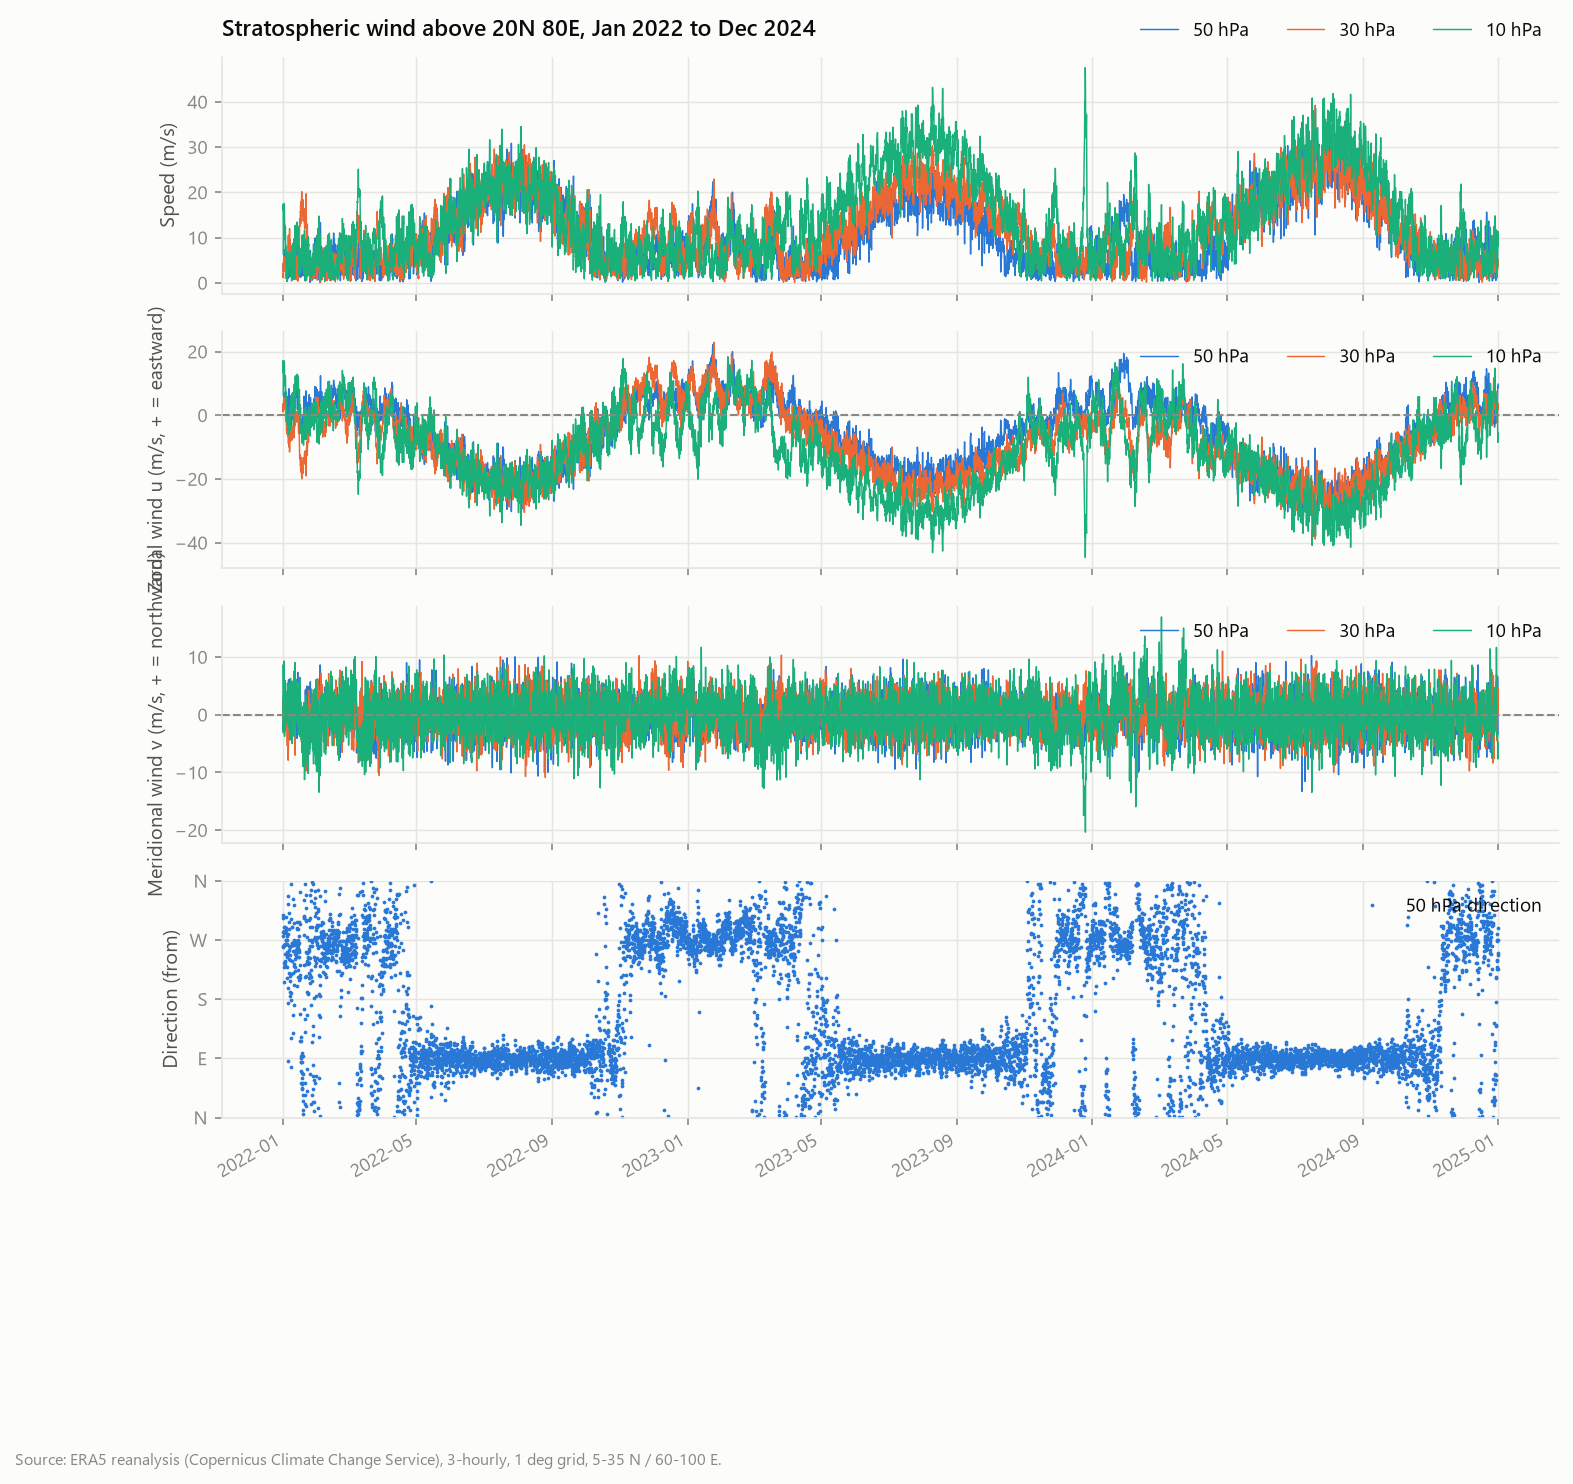

In [4]:
eda.fig_series(df)
from IPython.display import Image, display
display(Image(str(C.FIGURES / "eda_timeseries_full.png")))

## 4. Seasonal structure

The sign of the zonal wind is the regime. Over South Asia the 50 hPa flow runs
easterly through the monsoon season and reverses in winter, and that reversal is
the single largest source of variance in the record.

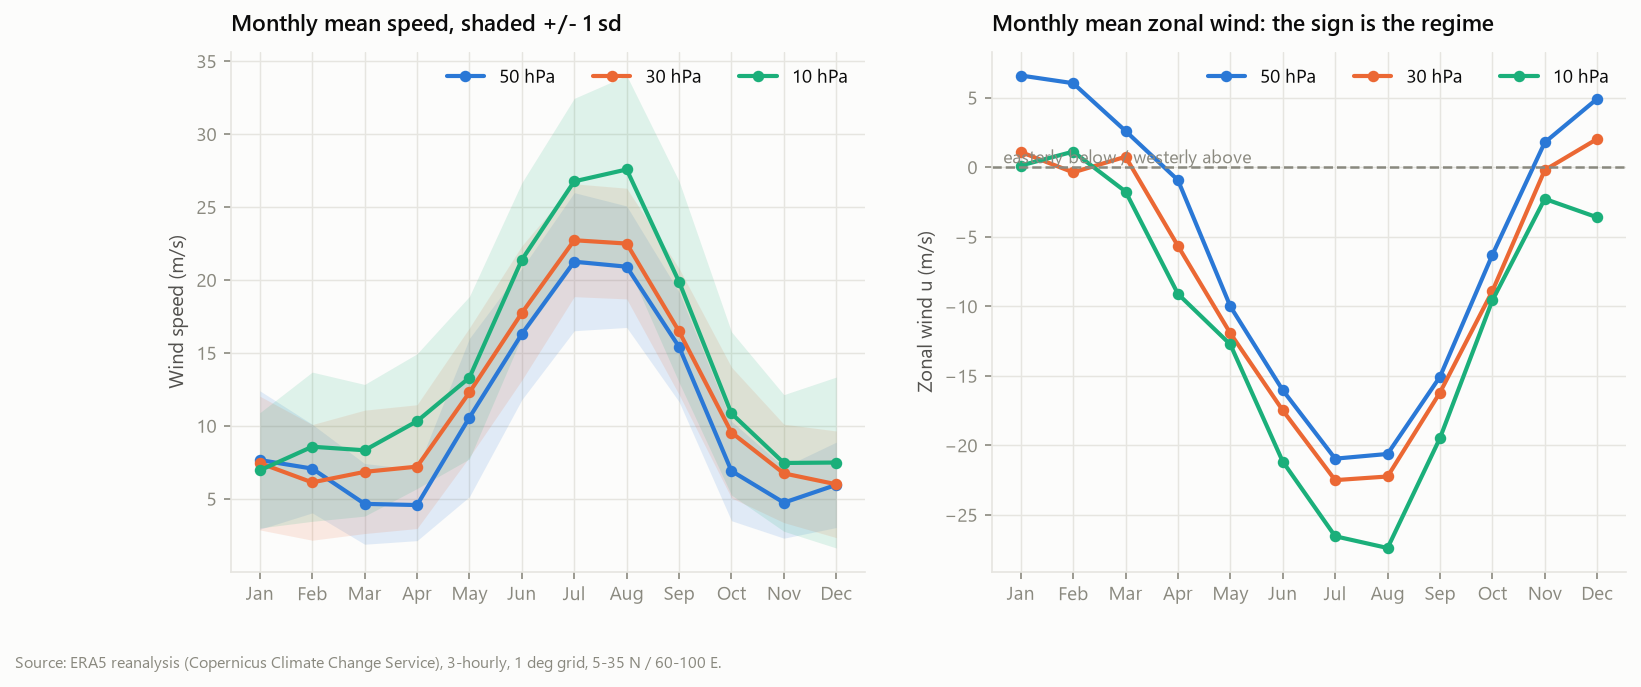

In [5]:
eda.fig_monthly(df)
display(Image(str(C.FIGURES / "eda_seasonal_cycle.png")))

## 5. Wind shear between levels

Shear matters twice over. It is a predictor, because the levels above the float
altitude lead changes at it. It is also an opportunity, because an airship that
can change altitude can pick the level with the least wind.

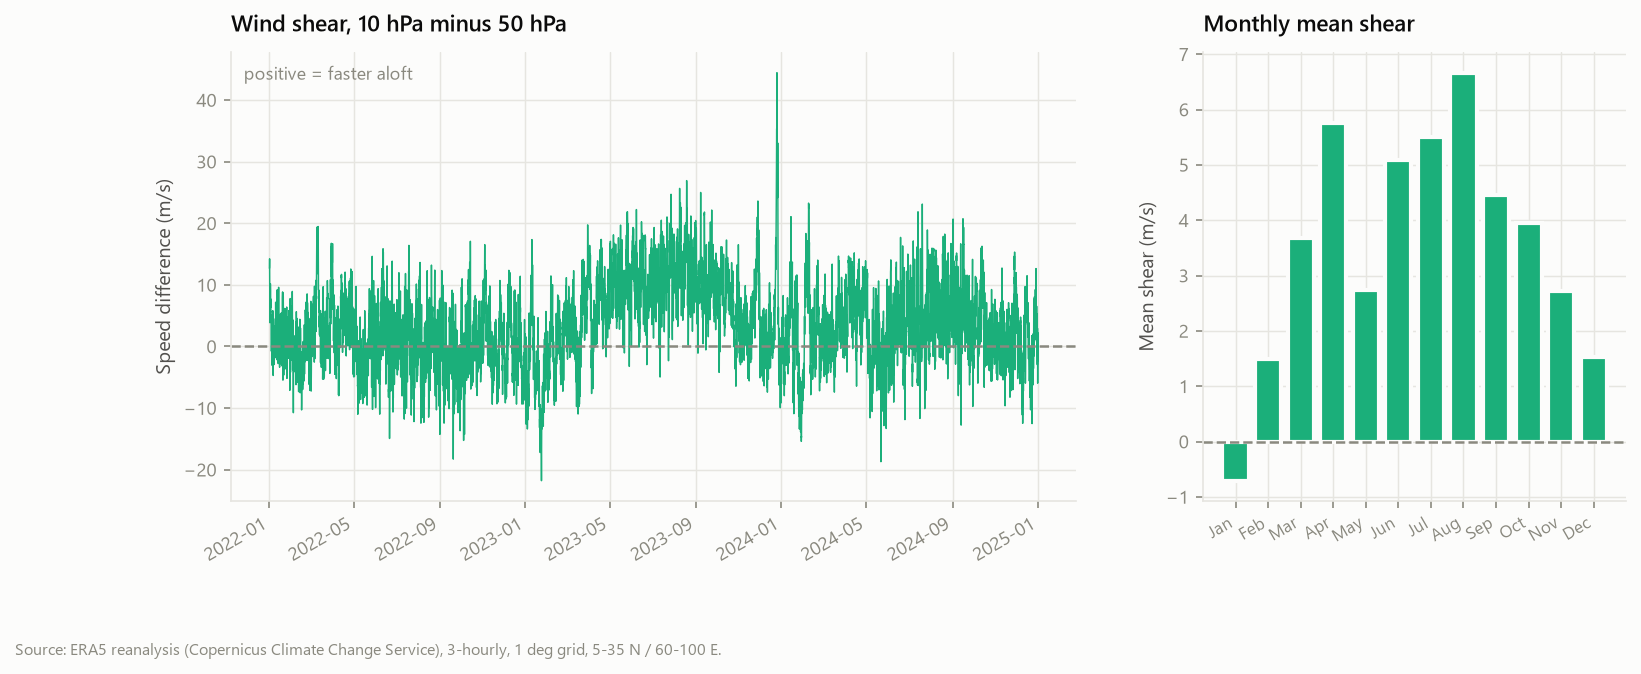

In [6]:
eda.fig_shear(df)
display(Image(str(C.FIGURES / "eda_wind_shear.png")))

## 6. Direction distribution

The rose shows how strongly the direction is concentrated. A concentrated rose
means a station-keeping controller mostly fights wind from a predictable
quarter.

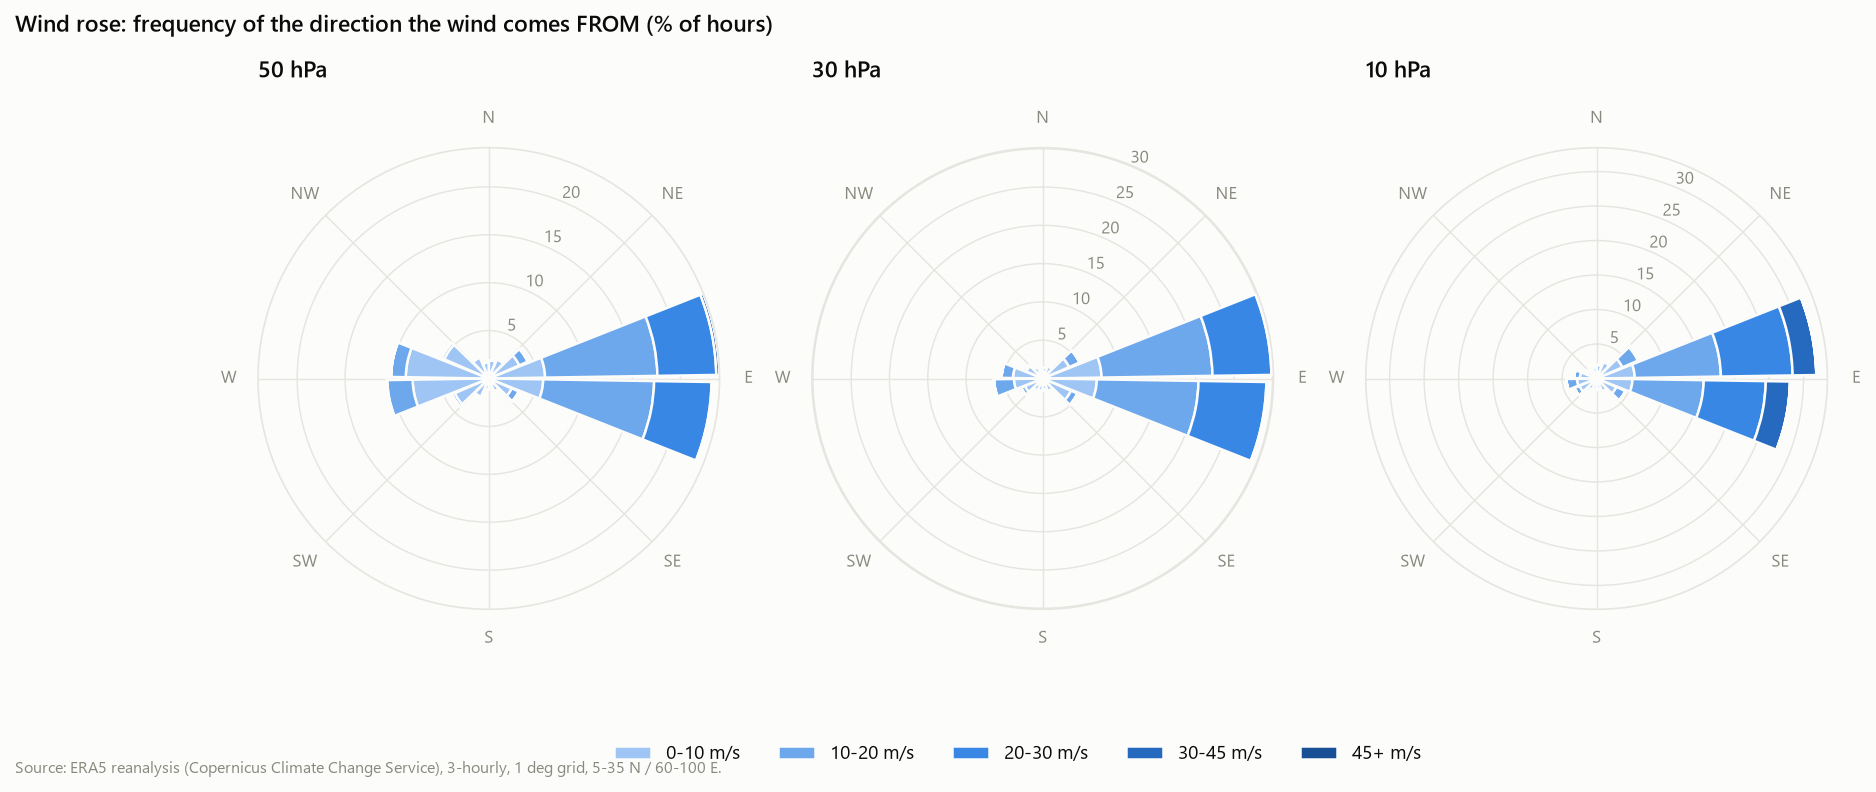

In [7]:
eda.fig_roses(df)
display(Image(str(C.FIGURES / "eda_wind_roses.png")))

## 7. Is this predictable at 6-24 hours?

This is the question that decides whether the project is worth doing.
Autocorrelation at the forecast horizons tells us how much of the answer
persistence already gets for free, which is exactly why persistence is the
baseline to beat rather than a straw man.

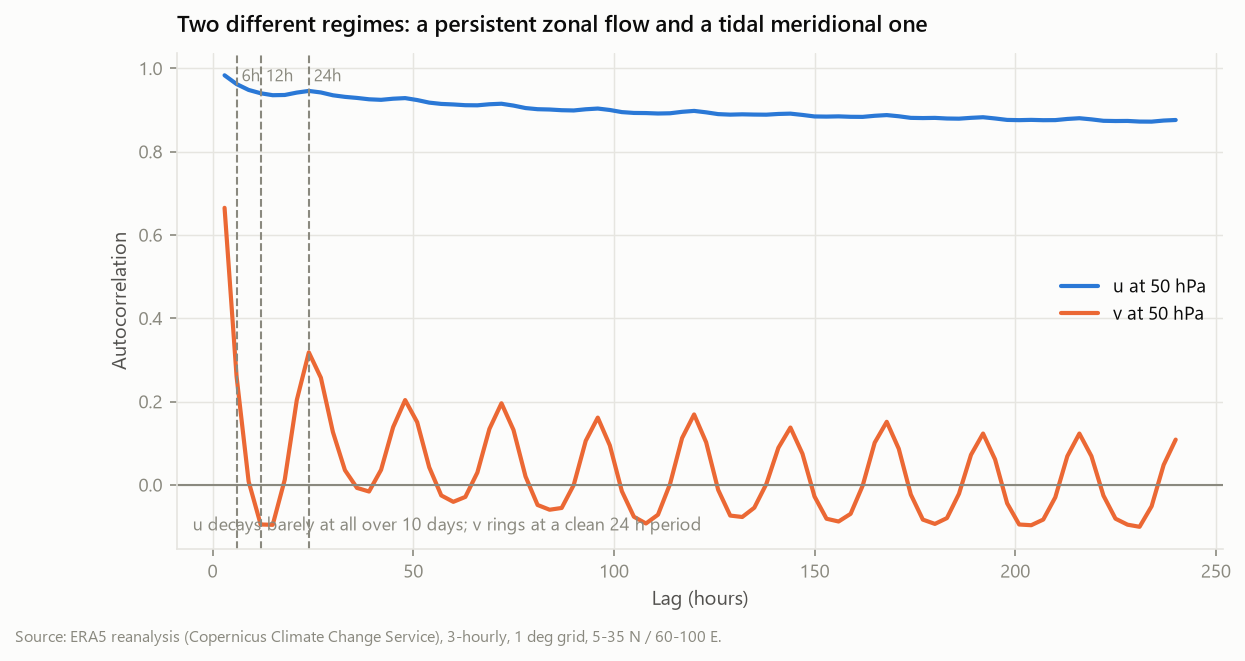

In [8]:
eda.fig_autocorr(df)
display(Image(str(C.FIGURES / "eda_autocorrelation.png")))

## 8. Data quality

ERA5 is a reanalysis, so it is gap-free by construction; this figure exists to
prove that for this extract rather than assume it, and to catch a download that
silently dropped a month.

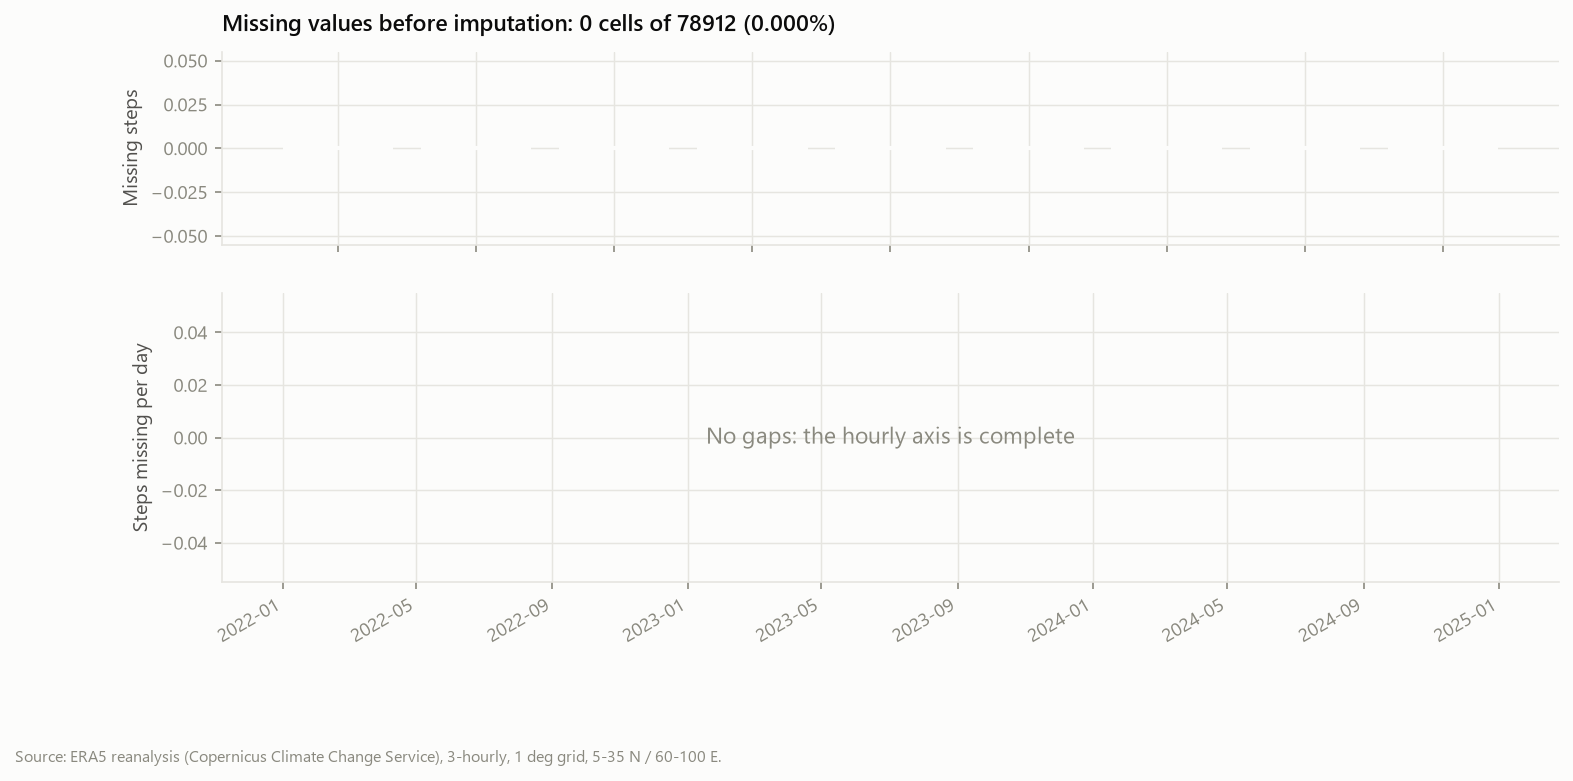

In [9]:
eda.fig_missing(missing, df)
display(Image(str(C.FIGURES / "eda_missing_data.png")))

## 9. The spatial picture

The station is one column in a domain that reverses with the season. The map
gives the context a single time series cannot.

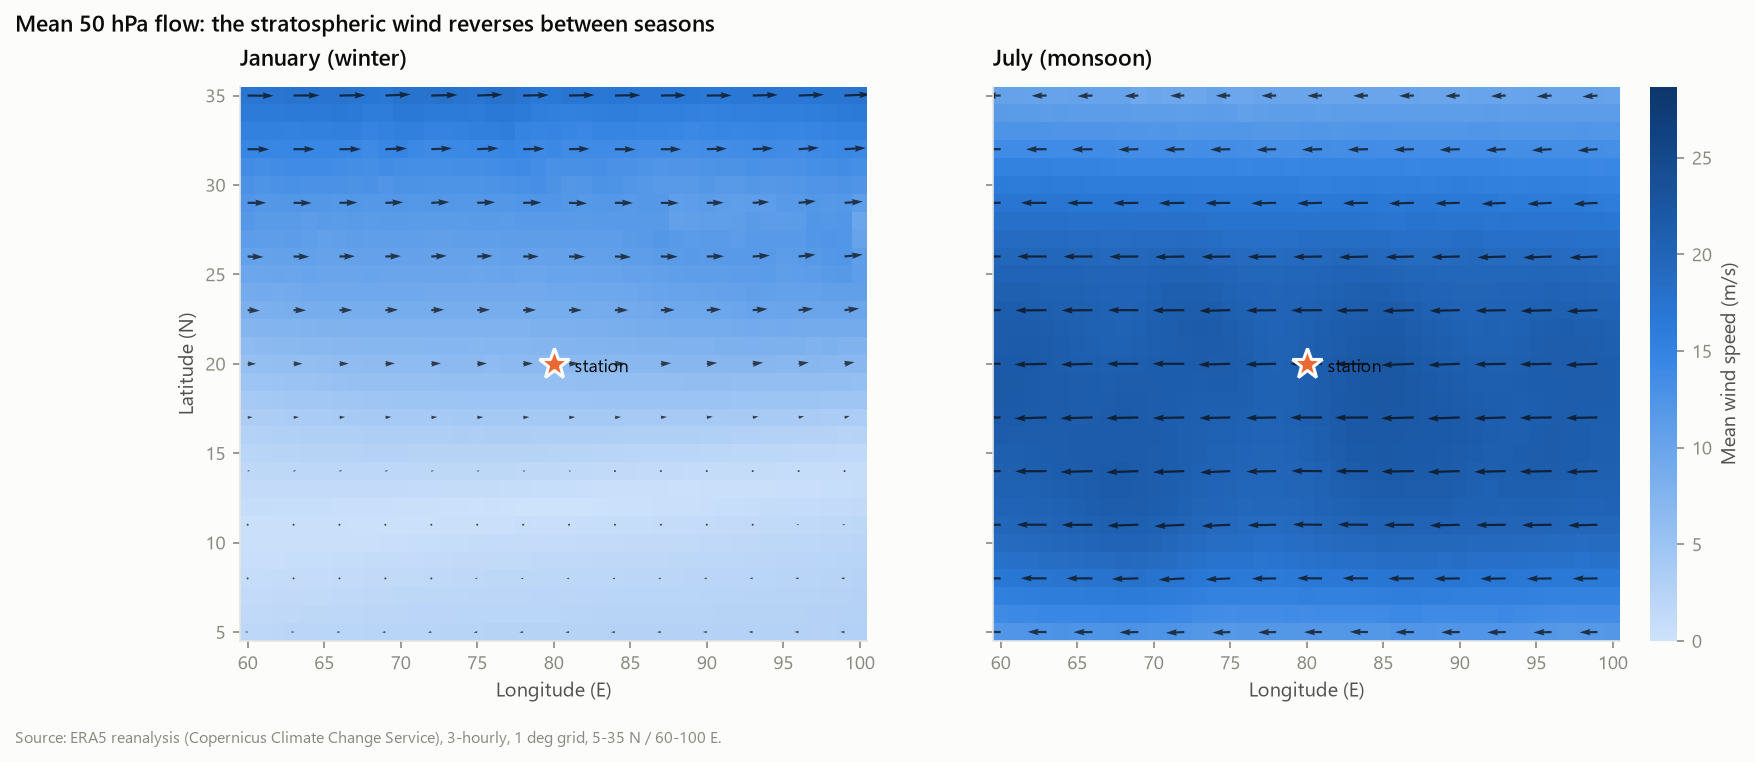

In [10]:
eda.fig_spatial(ds)
display(Image(str(C.FIGURES / "eda_spatial_mean_flow.png")))

## 10. What this implies for the model

- The series is smooth and strongly autocorrelated at 6-24 h, so **persistence is
  a strong baseline** and any model has to be scored against it.
- The seasonal reversal dominates the variance, so the train/val/test split has
  to be **chronological**; a random split would leak the regime and flatter the
  model.
- Levels above the float altitude carry information about it, which is why the
  input is the whole **(u, v, T) column at 50/30/10 hPa** rather than 50 hPa
  alone.
- Direction is unstable when the wind is weak, so directional accuracy is scored
  only where the wind is strong enough for a bearing to mean anything.

Next: `python src/train.py`, then `python src/evaluate.py`.